# **Notebook para Tesis**

Aqui hare el analisis y seleccion de caracteristicas

In [1]:
# Importar librerias necesarias

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Interpolación
from scipy.interpolate import PchipInterpolator

## dotenv
from dotenv import load_dotenv
# Cargar variables de entorno
load_dotenv()

True

## **Lectura de Archivos**

In [2]:
from data_load import get_pulses_df

files_amount = 1 ## Número de archivos a cargar, 0 para cargar todos
data = get_pulses_df(os.getenv("pulses_csv_path"), files_amount) # type: ignore ## Cargar datos 

In [3]:
data

,Unnamed: 0,s_0,s_1,s_2,s_3,s_4,s_5,s_6,s_7,s_8,s_9,s_10,s_11,s_12,s_13,s_14,s_15
0,25,50,37,27,17,4,6,2,1,0,0,0,0,0,0,0,0
1,39,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,54,2,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,55,44,27,15,11,6,5,0,0,1,0,0,0,0,0,0,0
4,64,20,19,11,1,5,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
959437,4666399,84,54,24,13,9,5,1,0,0,2,1,0,0,0,0,0
959438,4666402,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
959439,4666411,1,2,2,0,1,0,0,0,0,0,0,0,0,0,0,0
959440,4666412,4,2,0,1,0,0,0,0,0,0,0,0,0,0,0,0


### **Muestreo de Datos**

In [7]:
# Muestro los datos
print(data.head())

   Unnamed: 0  s_0  s_1  s_2  s_3  s_4  s_5  s_6  s_7  s_8  s_9  s_10  s_11  \
0          25   50   37   27   17    4    6    2    1    0    0     0     0   
1          39    1    0    0    0    0    0    0    0    0    0     0     0   
2          54    2    3    0    0    0    0    0    0    0    0     0     0   
3          55   44   27   15   11    6    5    0    0    1    0     0     0   
4          64   20   19   11    1    5    0    0    0    0    0     0     0   

   s_12  s_13  s_14  s_15  
0     0     0     0     0  
1     0     0     0     0  
2     0     0     0     0  
3     0     0     0     0  
4     0     0     0     0  


## **Interpolación**

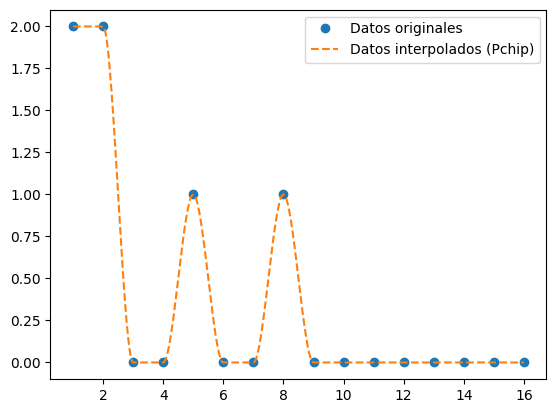

In [8]:
test = data.iloc[10, 1:].values # Tomo la segunda fila de data

x = np.arange(1, len(test)+1) 
y = test 

# cs = CubicSpline(x[mask], y[mask]) 
p = PchipInterpolator(x, y) 
xnew = np.linspace(1, len(test), num=1000)
ynew = p(xnew)

plt.plot(x, y, 'o', label='Datos originales') 
# plt.plot(xnew, cs(xnew), '-', label='Datos interpolados (Spline Cúbico)') #Conecta los puntos pero desvia de ellos un poco 
plt.plot(xnew, ynew, '--', label='Datos interpolados (Pchip)') #Conecta los puntos de manera suave
plt.legend()
plt.show()

In [4]:
from features import calculate_all_features
import time 

features_list = []

start_time = time.time()

for index, row in data.iterrows():
    features = calculate_all_features(row[1:].values) # type: ignore
    features_list.append(features)

    # Print counter with percentage
    progress = (index + 1) / len(data) * 100
    print(f"\rProcesando fila: {index} ({progress:.1f}%)", end='', flush=True)

features_df = pd.DataFrame(features_list)

end_time = time.time()
elapsed_time = end_time - start_time
print(f"\nTiempo total de procesamiento: {elapsed_time} segundos")
features_df.to_csv("features_output_1.csv.gz", index=False, compression='gzip')

Procesando fila: 959441 (100.0%)
Tiempo total de procesamiento: 2246.513683080673 segundos


In [25]:
features_df.to_csv("features_output_1.csv.gz", index=False, compression='gzip')